In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#nicer defaults
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

#load data
titanic = sns.load_dataset('titanic')
#light tidy : cast categories , drop obvious junk column if needed
cat_cols = ['sex', 'class', 'embark_town', 'who', 'adult_male', 'deck', 'embarked', 'alive','embarked']
for c in cat_cols:
    titanic[c] = titanic[c].astype('category')

titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


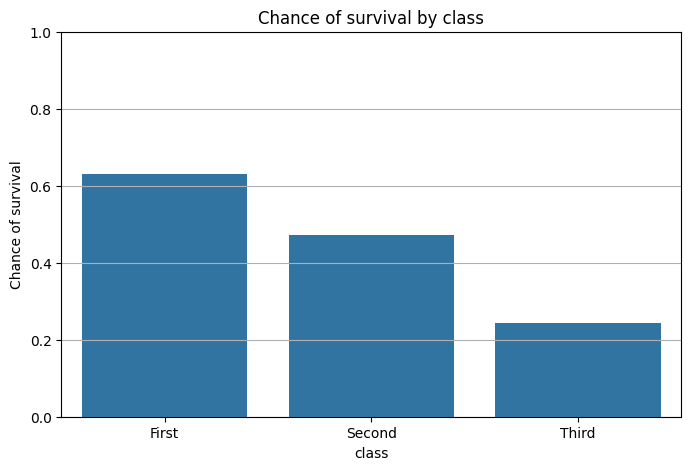

In [12]:
#plot the chance of survival by class 
sns.barplot(data=titanic, x='class', y='survived', errorbar=None)
plt.title('Chance of survival by class')
plt.ylabel('Chance of survival')
plt.ylim(0,1)
plt.show()

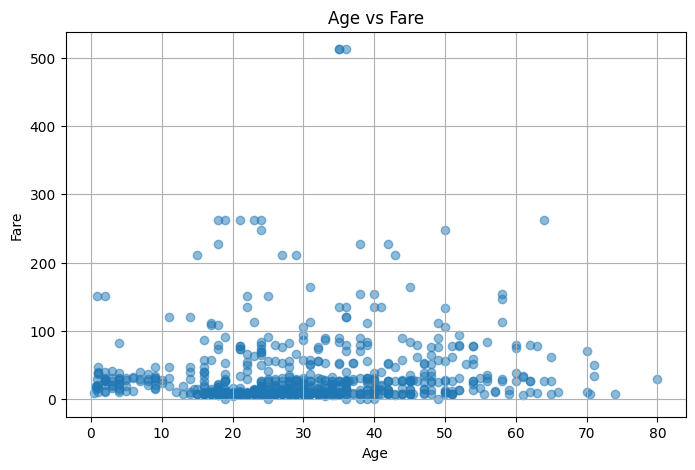

In [16]:
#scatter plot of age vs fare
df = titanic.dropna(subset=['age','fare'])
plt.scatter(df['age'], df['fare'],alpha=0.5)
plt.title('Age vs Fare')
plt.xlabel('Age')   
plt.ylabel('Fare')
plt.show()

In [ ]:
# Count plot of passengers by class and Sex
sns.countplot(data=titanic, x='class', hue='sex')
plt.title('Count by Class and Sex')
plt.show()

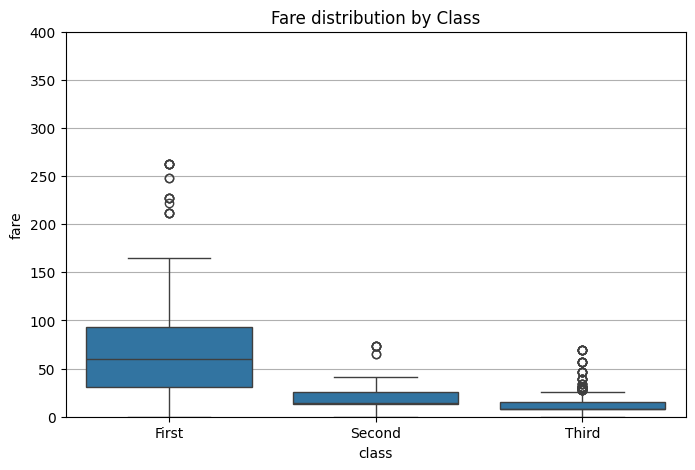

In [7]:
# Box plot of fare by class
sns.boxplot(data=titanic, x='class', y='fare')
plt.title('Fare distribution by Class')
plt.ylim(0,400)
plt.show()

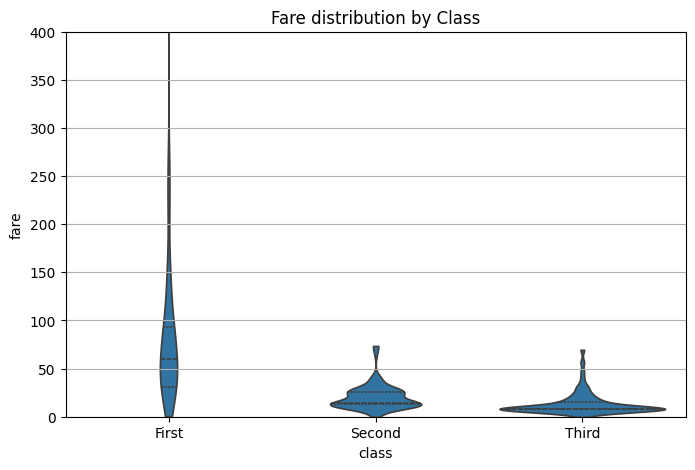

In [ ]:
# Violin plot of fare by class
sns.violinplot(data=titanic, x='class', y='fare', inner='quartile', cut=0)
plt.title('Fare distribution by Class')
plt.ylim(0,400)
plt.show()

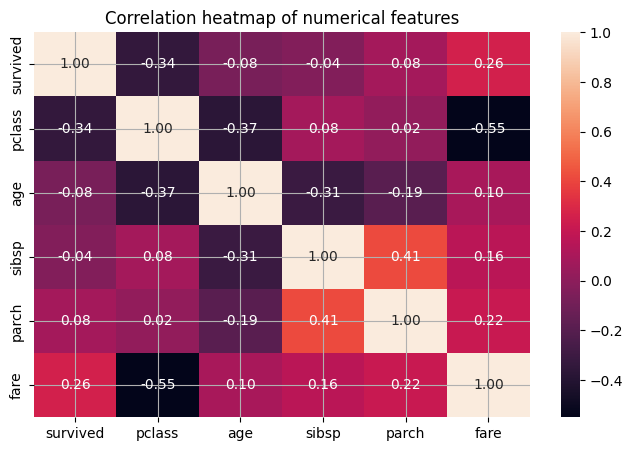

In [9]:

# Pair plot of numerical features
num = titanic.select_dtypes(include=['number'])
sns.heatmap(num.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title('Correlation heatmap of numerical features')
plt.show()

# What is each draph is good for

- Countplot: Categotrical frequesmcies 
- Boxplot : Summary of dictribution (median, spread, outliers)
- VIolinplot : full shape of teh distribution (density)
- Heatmap : matrix of correlation between mumeric column 

Task: comppare fare distribution by sex within class using 'sns.boxplot' with hue =sex. Limit fares to 0-400

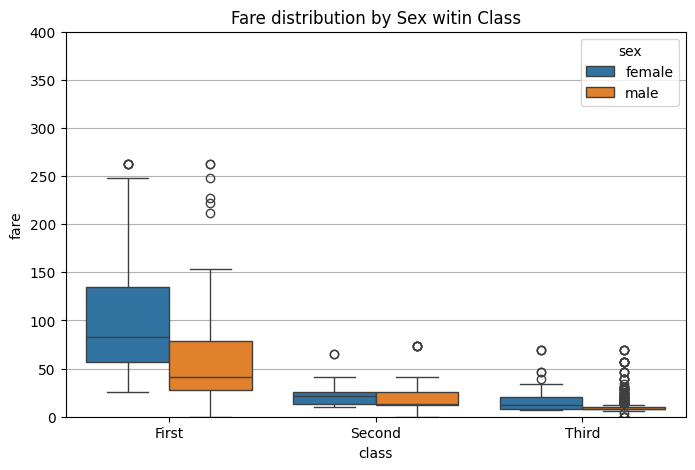

In [5]:
sns.boxplot(data=titanic, x='class', y='fare', hue='sex')
plt.title('Fare distribution by Sex witin Class')
plt.ylim(0,400)
plt.show()


Use sns.scatterplot to plot age vs fare with hue=survived and style =sex

C:\Users\Hp 2022\AppData\Local\Temp\ipykernel_25504\1678414957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['survived'] = df['survived'].replace({1: 'Yes', 0: 'No'})


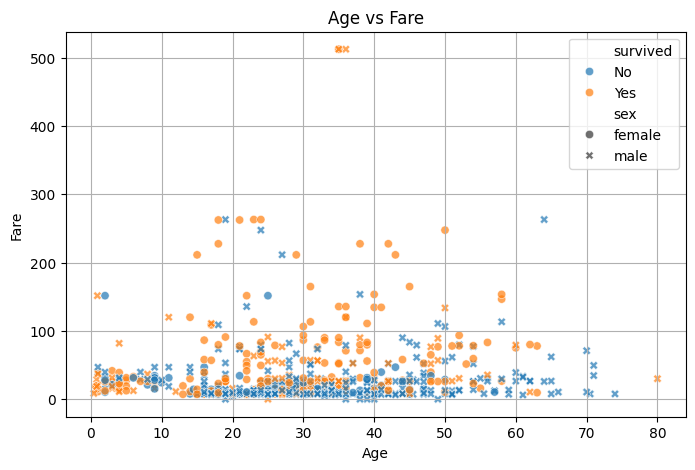

In [ ]:


# Remove rows where ANY of these columns have missing values
df = titanic.dropna(subset=['age','fare','survived','sex'])
# Map survived from 0,1 to No, Yes
df['survived'] = df['survived'].replace({1: 'Yes', 0: 'No'})

sns.scatterplot(data=df, x='age',  y='fare', hue='survived',  style='sex',alpha=0.7)
plt.title('Fare distribution by age grouped Class')
plt.title('Age vs Fare')
plt.xlabel('Age')   
plt.ylabel('Fare')
plt.show()

## Plotly

In [ ]:
df = titanic.dropna(subset=['age','fare','class','sex','embark_town'])
fig = px.scatter(
    df, x='age', y='fare', 
    color='class', symbol='sex',
    hover_data=['embark_town','alone','who'],
    range_y=[0,400],
    title='Age vs Fare - Interactive')

fig.show()

Build an interative plotly histogram of age with:
- Color by Sex
- nbins=30
- titile + x/y labels 
- filterout age nulls
- 

In [14]:
# Filter out null ages
df_filtered = titanic.dropna(subset=['age','sex'])

fig = px.histogram(
    df_filtered,
    x='age',
    color='sex',
    nbins=30,
    barmode='overlay',
    opacity=0.7,    
    title='Age Distribution by Sex')

fig.update_layout( xaxis_title='Age', yaxis_title='Count')

fig.show()

In [ ]:
# ADD FITERING WITH DROPDOWN

# this drops rows with missing values, copy avoids Pandas warnings when you add a new column
df = titanic.dropna(subset=["sex","class","survived"]).copy()

# gets the mean group rate (so every row carries its groups survival rate)
df["survival_rate"] = df.groupby(["sex","class"])["survived"].transform("mean")

# collapse to one group per row
agg = df.drop_duplicates(subset=["sex","class"])[["sex","class","survival_rate"]]
# agg.head()
# start with the default slice before we add a dropdown
fig = px.bar(
    agg.query("sex=='male'"),
    x="class", y="survival_rate",
    title="Survival Rate by Class — Filter by Sex"
)

# add dropdown to switch sex
fig.update_layout(
    updatemenus=[{
        "buttons":[
            {"label":"Male","method":"update",
             "args":[{"x":[agg.query('sex==\"male\"')["class"]],
                      "y":[agg.query('sex==\"male\"')["survival_rate"]]},
                     {"title":"Survival Rate by Class — Male"}]},
            {"label":"Female","method":"update",
             "args":[{"x":[agg.query('sex==\"female\"')["class"]],
                      "y":[agg.query('sex==\"female\"')["survival_rate"]]},
                     {"title":"Survival Rate by Class — Female"}]},
        ],
        "direction":"right", "x":0.5, "y":1.2
    }]
)
""" 
updatemenus adds a dropdown.
method:"update" lets you update both trace data and layout.
The first dict in args updates trace properties (x, y).
Plotly expects a list per trace → you have one trace, so you pass lists of length 1.
The second dict in args updates layout (here, the title).
Each button filters agg by sex and swaps the data in the existing trace.
"""

# Survival rate is a proportion, we do this to make the comparaion fair
fig.update_yaxes(range=[0,1], title="Survival Rate")
fig.show()

# Common Pitfalls & fixes
- Cluttered Legends: merge exocings or use direct lables/annotations.
- Inconsistent scales: align axis when comparing panels; limit or log-scale
- Too many colours: try to use less than six distinct hues
- Forgetting titles/units: ALWAYS remember to title and give units
- Sampling bias: visuals reflect the data you have, add caveats (or use if influencing descisions).

# When to use
- **Matplotlib**: maximum control; templates for final static figures
- **Seaborn**: fast, beautiful statistics, great defaults
- **Plotly**: interaction & sharing; great for stakeholder demos and dashboards

# So a general rule of thumb:

- Explore in Seaborn
- Refine in Matplotlib
- Present interactively in Plotly (if needed).